# Assignment 1 - response
The difference between the two CustomImageDataset implementations is where the dataset indexing work happens. In the first version, the code rescans the folders and rebuilds the class dictionary repeatedly inside "__len__()" and "__getitem__()". In the second version, the image paths and class mapping are computed once in "__init__()" and then reused. Both versions return the same tensors and labels, but the second one is better for training because it avoids unnecessary disk operations and follows the intended PyTorch Dataset design where "__init__" prepares metadata and "__getitem__" only retrieves one sample. Therefore version 2 is the correct implementation for a real training pipeline.

In [47]:
# install GDAL
!apt-get update -y
!apt-get install -y gdal-bin libgdal-dev
!pip install -q GDAL==$(gdal-config --version)


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (4,114 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [48]:
from google.colab import drive
drive.mount('/content/drive')
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import os
import random
from glob import glob
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from osgeo import gdal
gdal.UseExceptions()   # raise exceptions

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="osgeo.gdal"
)

In [50]:
DATA_ROOT = r"/content/drive/My Drive/MOISES_GEOG6855/Lab2/UCMerced_LandUse/Images"


In [51]:
def build_splits_ucmerced(data_root, seed=42):

    # for EACH class (100 imgs), randomly select:
    # 70 train, 10 validation (from remaining 30), 20 test
    # done per-class to guarantee the split ratio within each category
    rng = random.Random(seed)
    class_folders = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])

    train_items, val_items, test_items = [], [], []

    for class_idx, class_name in enumerate(class_folders):
        folder = os.path.join(data_root, class_name)

        paths = []
        paths += glob(os.path.join(folder, "*.tif"))
        paths = sorted(paths)

        if len(paths) != 100:
            print(f"WARNING: {class_name} has {len(paths)} imgs (wait 100).")

        # store selected samples in explicit lists
        # train_items / val_items / test_items hold (img_path, label_index)
        rng.shuffle(paths)

        train_p = paths[:70]      # 70 for training
        remaining = paths[70:]    # remaining 30
        val_p = remaining[:10]    # 10 for validation
        test_p = remaining[10:]   # 20 for testing

        train_items += [(p, class_idx) for p in train_p]
        val_items   += [(p, class_idx) for p in val_p]
        test_items  += [(p, class_idx) for p in test_p]

    # Feed lists into Dataset/DataLoader)
    return class_folders, train_items, val_items, test_items

class_names, train_items, val_items, test_items = build_splits_ucmerced(DATA_ROOT, seed=42)
num_classes = len(class_names)

len(train_items), len(val_items), len(test_items), num_classes, class_names[:5]


(1470,
 210,
 420,
 21,
 ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings'])

In [52]:
class UCMercedGDALDataset(Dataset):
    def __init__(self, items, out_size=(64, 64)):
        """
        items: list[(path, label)]
        out_size: (H, W) final for FC
        """
        self.items = items
        self.out_h, self.out_w = out_size

    def __len__(self):
        return len(self.items)

    def _read_gdal(self, path):
        ds = gdal.Open(path, gdal.GA_ReadOnly)
        if ds is None:
            raise FileNotFoundError(f"can't open with GDAL: {path}")

        arr = ds.ReadAsArray()
        ds = None

        # Handle single-band images so tensor shape is always (C,H,W)
        if arr.ndim == 2:
            arr = arr[None, :, :]  # (1,H,W)

        arr = arr.astype(np.float32)

        # Normalization for RGB 0-255
        if arr.max() > 1.5:
            arr = arr / 255.0

        return arr  # (C,H,W)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        x = self._read_gdal(path)  # (C,H,W)

        # Resize so Fully-Connected model is trainable (reduces input features)
        xt = torch.from_numpy(x).unsqueeze(0)  # (1,C,H,W)
        xt = torch.nn.functional.interpolate(
            xt, size=(self.out_h, self.out_w), mode="bilinear", align_corners=False
        )
        xt = xt.squeeze(0)  # (C,H,W)

        return xt, torch.tensor(label, dtype=torch.long)


In [53]:
# Dataset input is the selected (path,label) list
train_ds = UCMercedGDALDataset(train_items, out_size=(64,64))
val_ds   = UCMercedGDALDataset(val_items, out_size=(64,64))
test_ds  = UCMercedGDALDataset(test_items, out_size=(64,64))

# DataLoader outputs batches of (imgs, labels) for training/validation/testing
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


In [54]:
class FCNet(nn.Module):
    def __init__(self, in_ch=3, h=64, w=64, num_classes=21):
        super().__init__()
        in_features = in_ch * h * w

        # Fully Connected neural network (Linear layers) for image classification
        # at least 5 hidden layers
        # activation is NOT ReLU (using GELU)
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(in_features, 1024),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.GELU(),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FCNet(in_ch=3, h=64, w=64, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [55]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_n = 0

    with torch.set_grad_enabled(train_mode):
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            bs = x.size(0)
            total_loss += loss.item() * bs
            total_n += bs

    return total_loss / max(total_n, 1)

# train for at least 100 epochs
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    # training step each epoch
    tr_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    # validate at the end of each epoch
    va_loss = run_epoch(model, val_loader, criterion, optimizer=None)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")


Epoch 001/100 | train_loss=3.0584 | val_loss=3.0402
Epoch 005/100 | train_loss=2.9482 | val_loss=2.9541
Epoch 010/100 | train_loss=2.8344 | val_loss=2.8396
Epoch 015/100 | train_loss=2.6851 | val_loss=2.7618
Epoch 020/100 | train_loss=2.5922 | val_loss=2.6615
Epoch 025/100 | train_loss=2.4833 | val_loss=2.6537
Epoch 030/100 | train_loss=2.4330 | val_loss=2.5781
Epoch 035/100 | train_loss=2.3269 | val_loss=2.8959
Epoch 040/100 | train_loss=2.2399 | val_loss=2.9657
Epoch 045/100 | train_loss=2.1664 | val_loss=2.7255
Epoch 050/100 | train_loss=2.1393 | val_loss=2.8984
Epoch 055/100 | train_loss=2.1213 | val_loss=3.0623
Epoch 060/100 | train_loss=1.9655 | val_loss=2.8998
Epoch 065/100 | train_loss=2.0516 | val_loss=3.0330
Epoch 070/100 | train_loss=2.0587 | val_loss=3.3238
Epoch 075/100 | train_loss=1.8574 | val_loss=3.1778
Epoch 080/100 | train_loss=2.0228 | val_loss=3.2053
Epoch 085/100 | train_loss=1.7731 | val_loss=3.3162
Epoch 090/100 | train_loss=1.6936 | val_loss=3.8681
Epoch 095/10

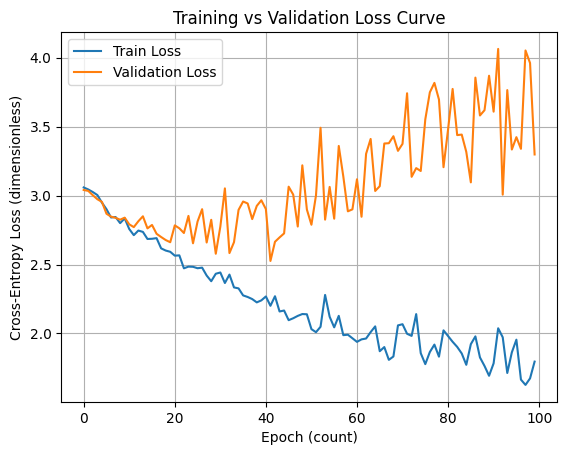

In [56]:
# display training loss and validation loss curves
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch (count)")
plt.ylabel("Cross-Entropy Loss (dimensionless)")
plt.title("Training vs Validation Loss Curve")

plt.legend()
plt.grid(True)
plt.show()


In [57]:
# save trained model weights as a .ckpt file
CKPT_PATH = "/content/drive/MyDrive/MOISES_GEOG6855/Lab2/ucmerced_fcnet.ckpt"
torch.save(model.state_dict(), CKPT_PATH)
print("Saved:", CKPT_PATH)


Saved: /content/drive/MyDrive/MOISES_GEOG6855/Lab2/ucmerced_fcnet.ckpt


In [58]:
from sklearn.metrics import confusion_matrix

# load the saved .ckpt and run inference
model2 = FCNet(in_ch=3, h=64, w=64, num_classes=num_classes).to(device)
model2.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model2.eval()

all_preds = []
all_true = []

# run inference on the randomly picked TEST dataset
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model2(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.append(preds)
        all_true.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

# confusion matrix + OA, precision, recall
cm = confusion_matrix(all_true, all_preds, labels=list(range(num_classes)))
cm.shape


(21, 21)

In [59]:
# compute OA, precision, recall from confusion matrix

oa = np.trace(cm) / np.sum(cm)

precision_per_class = np.diag(cm) / np.maximum(cm.sum(axis=0), 1)  # TP / (TP+FP)
recall_per_class    = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)  # TP / (TP+FN)

precision_macro = np.mean(precision_per_class)
recall_macro    = np.mean(recall_per_class)

print(f"OA: {oa:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")


OA: 0.1905
Precision (macro): 0.2229
Recall (macro): 0.1905


In [60]:
for i, name in enumerate(class_names):
    print(f"{name:20s} | P={precision_per_class[i]:.3f} | R={recall_per_class[i]:.3f}")


agricultural         | P=0.036 | R=0.100
airplane             | P=0.167 | R=0.050
baseballdiamond      | P=0.333 | R=0.300
beach                | P=0.429 | R=0.150
buildings            | P=0.111 | R=0.050
chaparral            | P=0.542 | R=0.650
denseresidential     | P=0.091 | R=0.050
forest               | P=0.389 | R=0.700
freeway              | P=0.556 | R=0.250
golfcourse           | P=0.200 | R=0.150
harbor               | P=0.000 | R=0.000
intersection         | P=0.333 | R=0.050
mediumresidential    | P=0.026 | R=0.050
mobilehomepark       | P=0.192 | R=0.250
overpass             | P=0.129 | R=0.200
parkinglot           | P=0.103 | R=0.200
river                | P=0.140 | R=0.300
runway               | P=0.500 | R=0.250
sparseresidential    | P=0.300 | R=0.150
storagetanks         | P=0.000 | R=0.000
tenniscourt          | P=0.105 | R=0.100
